---
title: Solving LinkedIn Mini Sudoku with Linear Optimization
short_title: How to Solve Mini Sudoku
date: 2025-10-29
downloads:
    - file: 4-mini-sudoku.ipynb
      title: This Notebook
      filename: mini-sudoku.ipynb
    - url: https://github.com/rodrigo-cl-porto/Solving-LinkedIn-Games-by-Linear-Optimization/blob/main/linkedin_games/sudoku/sudoku.py
      title: sudoku.py
---

![Mini Sudoku Banner](../assets/2-how-to-solve/4-mini-sudoku/banner.jpg)

# What is Sudoku?

:::{figure} ../assets/2-how-to-solve/4-mini-sudoku/classic-sudoku.png
:label: classic-sudoku
:alt: Classic Sudoku table
:align: center
:width: 60%
Example of a classic Sudoku puzzle. _Source: [Wikipedia](https://en.wikipedia.org/wiki/Sudoku)_
:::

Mini Sudoku is based on the classic Sudoku game (from the Japanese 数独, meaning _unique numbers_ in a free translation), which originally consists of a 9 $\times$ 9 grid and 9 smaller 3 $\times$ 3 matrices, with some squares already pre-filled with digits from 1 to 9. The meaning of its name is due to its objective of filling all the squares without repeating digits in the rows, columns, and smaller grids.

# How to Play Mini Sudoku

:::{figure} ../assets/2-how-to-solve/4-mini-sudoku/example.mp4
:alt: Mini Sudoku Example
:label: mini-sudoku-example
:align: center
:width: 60%
Example of a Mini Sudoku game. _Source: [LinkedIn Mini Sudoku](https://www.linkedin.com/games/mini-sudoku)_
:::

In the case of Mini Sudoku, the game consists of a grid with smaller dimensions than the classic, 6 $\times$ 6 grid, composed of six 2 $\times$ 3 submatrices.

Objective
: Fill all the empty spaces in the game grid with digits from 1 to 6

Rules
: Each row, column, and mini-grid of the main game matrix must be filled with a digit from 1 to 6, without repetition in each row, column, or smaller grid.

# Problem Modeling

As I did in my previous articles, the LO model for the Mini Sudoku game requires the definition of the following components:

- **Ranges**
- **Sets**
- **Objective function**
- **Decision Variables**
- **Constraints**

First, let's define these components considering the most general scenario for building the Abstract Model for the Sudoku game before defining them for the more specific case of Mini Sudoku.

## Ranges

In order to consider the most general cases, five ranges will be considered: $I$ and $J$ to represent the dimensions of the main grid, $U$ and $V$ for the dimensions of the smaller grids, and an interval $K$ for the range of possible values a square can receive.

$I = \{1, \cdots, n\}$
: The row range, where $n$ is the total number of rows (in this case, $n = 6$)

$J = \{1, \cdots, n\}$
: The column range, where the total number of columns is equal to the number of rows for dealing with a square matrix

$K = \{1, \cdots, n\}$
: Range of possible values, where $n$ is the total number of possible digits, which is expected to be equal to the $n$ dimensions of the grid

$U = \{1, \cdots, p\}$
: Number of rows in the game's submatrices, where $p$ is the total number of rows in each submatrix

$V = \{1, \cdots, q\}$
: Number of columns in the game's submatrices, where $q$ is the total number of columns in each submatrix, which is expected to be $pq = n$, that is, the number of squares in each submatrix should be equal to the number of possible digits.

## Sets

To facilitate the definition of the constraints, it is important to define at least the set $S$ of submatrices and $F$ of pre-filled squares. Furthermore, it is necessary to clearly define which squares of the board comprise each of the submatrices $S_{vu}$. For example, the first submatrix $S_{11}$ is composed of squares in rows 1 and 2 and columns whose index ranges go from 1 to 3. $S_{12}$ is also composed of squares in rows 1 and 2, but the column indices range from 4 to 6, which is the second half of the column range; and so on for the remaining $S_{vu}$.

:::{note}
The indices of the $v$ and $u$ of the submatrices correspond respectively to the indices of the columns and rows. The order is reversed because, for submatrices of dimensions 2 $\times$ 3, their arrangement in the main matrix is in the 3 $\times$ 2 format.
:::

$S = \{S_{vu} \mid \forall v \in V, \forall u \in U\}$
: Set of submatrices $S_{vu}$ existing in the game

$S_{vu} = \{(i, j) \mid \forall i \in \{p(v-1)+1, \cdots, pv\}, \forall j \in \{q(u-1)+1, \cdots, qu\}\}$
: Set of squares $(i, j) \subseteq I \times J$ that belong to the submatrix $S_{vu}$

$F = \{(i, j, k) \mid i \in I, j \in J, k \in K\} \subseteq I \times J \times K$
: Subset of pre-filled squares.

## Decision Variables

The decision variables will be binary $x_{ijk}$, representing the decision of whether square $(i, j)$ is filled with the value $k$. Therefore, as with the models of the other LinkedIn minigames, the Mini Sudoku is a BLOP.

$x_{ijk} \in \B, \forall (i,j,k) \in I \times J \times K$
: $x_{ijk} = 1$ if square $(i,j)$ is filled with the digit $k$
: $x_{ijk} = 0$ otherwise.

## Objective Function

Once again, as in previous articles, the Sudoku optimization problem does not have a function to be optimized, since we only want to find a solution that satisfies all the rules of the game. Therefore, the BLPP is a feasibility problem, whose objective function consists of maximizing (or minimizing) an arbitrary constant.

$$\text{Max} \ C$$

## Constraints

Finally, with all the previously defined components, let's translate the Sudoku rules into mathematical formulations for the BLOP model.

Binary Constraints
: First of all, it's important to clearly state the binary nature of the decision variables in the constraint set.
: $$x_{ijk} \in \{0, 1\}, \forall (i, j, k) \in I \times J \times K $$

Unique-Digits-Per-Row Constraints
: Since there can be no repetition of values for each row, the sum of the $x_{ijk}$ for each row $i$ must be equal to 1, and there must be a such constraint for column $j$ and for each digit $k$, which in the case of Mini Sudoku will result in 36 constraints.
: $$\sum_{j \in J}{x_{ijk}}=1, \forall i \in I, \forall k \in K$$

Unique-Digits-Per-Column Constraints
: The same logic applies to each column $j$ of the game, with one constraint for each row $i$ and possible digit $k$, resulting in 36 more constraints.
: $$\sum_{i \in I}{x_{ijk}}=1, \forall j \in J, \forall k \in K$$

Unique-Digits-Per-Submatrix Constraints
: With the set $S$ of submatrices already well defined, it becomes easier to define the set of constraints that prevent repetition of digits for each submatrix $S_{vu}$.
: $$\sum_{(i,j) \in S_{vu}}{x_{ijk}}=1, \forall S_{vu} \in S, \forall k \in K$$

Single-Digit-Per-Square Constraints
: In addition, it is necessary to impose a set of constraints to prevent a square from being filled with more than one digit, which is achieved if the sum of $x_{ijk}$ is equal to 1 for each square $(i, j)$ existing in the game; therefore, 36 more constraints in the case of Mini Sudoku.
: $$\sum_{k \in K}{x_{ijk}}=1, \forall i \in I, \forall j \in J$$

Already-Filled-Squares Constraints
: Finally, for each already filled square, we must remember to impose that $x_{ijk} = 1$ if the square $(i, j)$ is already filled with the digit $k$.
: $$x_{ijk}=1, \forall (i,j,k) \in F$$

# Abstract Model

With all the components set, we now have assembled the abstract model for a Sudoku game. It's important to remember that this model assumes the game's submatrices will be rectangular with dimensions $p \times q$, such that $pq = n$.

:::{math}
:enumerated: false
\text{Min} \ C
:::

$$
\begin{array}{lll}
    \text{S.t.:} & & \\
    & \sum_{i \in I}{x_{ijk}}=1, & \forall j \in J, \forall k \in K \\
    & \sum_{j \in J}{x_{ijk}}=1, & \forall i \in I, \forall k \in K \\
    & \sum_{k \in K}{x_{ijk}}=1, & \forall i \in I, \forall j \in J \\
    & \sum_{(i,j) \in S_{vu}}{x_{ijk}}=1, & \forall S_{vu} \in S, \forall k \in K \\
    & x_{ijk}=1, & \forall (i, j,k) \in F \\
    & x_{ijk} \in \B, & \forall (i,j,k) \in I \times J \times K \\
\end{array}
$$

# Concrete Model

The example to be solved in this notebook will be Mini Sudoku No. 60, published on LinkedIn on October 10{sup}`th`, 2025

:::{figure} ../assets/2-how-to-solve/4-mini-sudoku/problem.png
:label: mini-sudoku-problem
:alt: Mini Sudoku No. 60
:width: 60%
:align: center
Mini Sudoku No. 60, October 10{sup}`th`, 2025 (_Source: [LinkedIn MiniSudoku](https://www.linkedin.com/games/mini-sudoku)_)
:::

Based on the abstract model, it is possible to instantiate a concrete model for this game, as shown below.

:::{math}
:enumerated: false
\text{Min} \ 0
:::

S.t.:

Unique-Digits-Per-Row Constraints
: $x_{111} + x_{121} + x_{131} + x_{141} + x_{151} + x_{161} = 1$ {sub}`(_Digit 1 on Row 1_)`
: $x_{211} + x_{221} + x_{231} + x_{241} + x_{251} + x_{261} = 1$ {sub}`(_Digit 1 on Row 2_)`
: $x_{311} + x_{321} + x_{331} + x_{341} + x_{351} + x_{361} = 1$ {sub}`(_Digit 1 on Row 3_)`
: $x_{411} + x_{421} + x_{431} + x_{441} + x_{451} + x_{461} = 1$ {sub}`(_Digit 1 on Row 4_)`
: $x_{511} + x_{521} + x_{531} + x_{541} + x_{551} + x_{561} = 1$ {sub}`(_Digit 1 on Row 5_)`
: $x_{611} + x_{621} + x_{631} + x_{641} + x_{651} + x_{661} = 1$ {sub}`(_Digit 1 on Row 6_)`
: $x_{112} + x_{122} + x_{132} + x_{142} + x_{152} + x_{162} = 1$ {sub}`(_Digit 2 on Row 1_)`
: $x_{212} + x_{222} + x_{232} + x_{242} + x_{252} + x_{262} = 1$ {sub}`(_Digit 2 on Row 2_)`
: $x_{312} + x_{322} + x_{332} + x_{342} + x_{352} + x_{362} = 1$ {sub}`(_Digit 2 on Row 3_)`
: $x_{412} + x_{422} + x_{432} + x_{442} + x_{452} + x_{462} = 1$ {sub}`(_Digit 2 on Row 4_)`
: $x_{512} + x_{522} + x_{532} + x_{542} + x_{552} + x_{562} = 1$ {sub}`(_Digit 2 on Row 5_)`
: $x_{612} + x_{622} + x_{632} + x_{642} + x_{652} + x_{662} = 1$ {sub}`(_Digit 2 on Row 6_)`
: $x_{113} + x_{123} + x_{133} + x_{143} + x_{153} + x_{163} = 1$ {sub}`(_Digit 3 on Row 1_)`
: $x_{213} + x_{223} + x_{233} + x_{243} + x_{253} + x_{263} = 1$ {sub}`(_Digit 3 on Row 2_)`
: $x_{313} + x_{323} + x_{333} + x_{343} + x_{353} + x_{363} = 1$ {sub}`(_Digit 3 on Row 3_)`
: $x_{413} + x_{423} + x_{433} + x_{443} + x_{453} + x_{463} = 1$ {sub}`(_Digit 3 on Row 4_)`
: $x_{513} + x_{523} + x_{533} + x_{543} + x_{553} + x_{563} = 1$ {sub}`(_Digit 3 on Row 5_)`
: $x_{613} + x_{623} + x_{633} + x_{643} + x_{653} + x_{663} = 1$ {sub}`(_Digit 3 on Row 6_)`
: $x_{114} + x_{124} + x_{134} + x_{144} + x_{154} + x_{164} = 1$ {sub}`(_Digit 4 on Row 1_)`
: $x_{214} + x_{224} + x_{234} + x_{244} + x_{254} + x_{264} = 1$ {sub}`(_Digit 4 on Row 2_)`
: $x_{314} + x_{324} + x_{334} + x_{344} + x_{354} + x_{364} = 1$ {sub}`(_Digit 4 on Row 3_)`
: $x_{414} + x_{424} + x_{434} + x_{444} + x_{454} + x_{464} = 1$ {sub}`(_Digit 4 on Row 4_)`
: $x_{514} + x_{524} + x_{534} + x_{544} + x_{554} + x_{564} = 1$ {sub}`(_Digit 4 on Row 5_)`
: $x_{614} + x_{624} + x_{634} + x_{644} + x_{654} + x_{664} = 1$ {sub}`(_Digit 4 on Row 6_)`
: $x_{115} + x_{125} + x_{135} + x_{145} + x_{155} + x_{165} = 1$ {sub}`(_Digit 5 on Row 1_)`
: $x_{215} + x_{225} + x_{235} + x_{245} + x_{255} + x_{265} = 1$ {sub}`(_Digit 5 on Row 2_)`
: $x_{315} + x_{325} + x_{335} + x_{345} + x_{355} + x_{365} = 1$ {sub}`(_Digit 5 on Row 3_)`
: $x_{415} + x_{425} + x_{435} + x_{445} + x_{455} + x_{465} = 1$ {sub}`(_Digit 5 on Row 4_)`
: $x_{515} + x_{525} + x_{535} + x_{545} + x_{555} + x_{565} = 1$ {sub}`(_Digit 5 on Row 5_)`
: $x_{615} + x_{625} + x_{635} + x_{645} + x_{655} + x_{665} = 1$ {sub}`(_Digit 5 on Row 6_)`
: $x_{116} + x_{126} + x_{136} + x_{146} + x_{156} + x_{166} = 1$ {sub}`(_Digit 6 on Row 1_)`
: $x_{216} + x_{226} + x_{236} + x_{246} + x_{256} + x_{266} = 1$ {sub}`(_Digit 6 on Row 2_)`
: $x_{316} + x_{326} + x_{336} + x_{346} + x_{356} + x_{366} = 1$ {sub}`(_Digit 6 on Row 3_)`
: $x_{416} + x_{426} + x_{436} + x_{446} + x_{456} + x_{466} = 1$ {sub}`(_Digit 6 on Row 4_)`
: $x_{516} + x_{526} + x_{536} + x_{546} + x_{556} + x_{566} = 1$ {sub}`(_Digit 6 on Row 5_)`
: $x_{616} + x_{626} + x_{636} + x_{646} + x_{656} + x_{666} = 1$ {sub}`(_Digit 6 on Row 6_)`

Unique-Digits-Per-Column Constraints
: $x_{111} + x_{211} + x_{311} + x_{411} + x_{511} + x_{611} = 1$ {sub}`(_Digit 1 on Column 1_)`
: $x_{121} + x_{221} + x_{321} + x_{421} + x_{521} + x_{621} = 1$ {sub}`(_Digit 1 on Column 2_)`
: $x_{131} + x_{231} + x_{331} + x_{431} + x_{531} + x_{631} = 1$ {sub}`(_Digit 1 on Column 3_)`
: $x_{141} + x_{241} + x_{341} + x_{441} + x_{541} + x_{641} = 1$ {sub}`(_Digit 1 on Column 4_)`
: $x_{151} + x_{251} + x_{351} + x_{451} + x_{551} + x_{651} = 1$ {sub}`(_Digit 1 on Column 5_)`
: $x_{161} + x_{261} + x_{361} + x_{461} + x_{561} + x_{661} = 1$ {sub}`(_Digit 1 on Column 6_)`
: $x_{112} + x_{212} + x_{312} + x_{412} + x_{512} + x_{612} = 1$ {sub}`(_Digit 2 on Column 1_)`
: $x_{122} + x_{222} + x_{322} + x_{422} + x_{522} + x_{622} = 1$ {sub}`(_Digit 2 on Column 2_)`
: $x_{132} + x_{232} + x_{332} + x_{432} + x_{532} + x_{632} = 1$ {sub}`(_Digit 2 on Column 3_)`
: $x_{142} + x_{242} + x_{342} + x_{442} + x_{542} + x_{642} = 1$ {sub}`(_Digit 2 on Column 4_)`
: $x_{152} + x_{252} + x_{352} + x_{452} + x_{552} + x_{652} = 1$ {sub}`(_Digit 2 on Column 5_)`
: $x_{162} + x_{262} + x_{362} + x_{462} + x_{562} + x_{662} = 1$ {sub}`(_Digit 2 on Column 6_)`
: $x_{113} + x_{213} + x_{313} + x_{413} + x_{513} + x_{613} = 1$ {sub}`(_Digit 3 on Column 1_)`
: $x_{123} + x_{223} + x_{323} + x_{423} + x_{523} + x_{623} = 1$ {sub}`(_Digit 3 on Column 2_)`
: $x_{133} + x_{233} + x_{333} + x_{433} + x_{533} + x_{633} = 1$ {sub}`(_Digit 3 on Column 3_)`
: $x_{143} + x_{243} + x_{343} + x_{443} + x_{543} + x_{643} = 1$ {sub}`(_Digit 3 on Column 4_)`
: $x_{153} + x_{253} + x_{353} + x_{453} + x_{553} + x_{653} = 1$ {sub}`(_Digit 3 on Column 5_)`
: $x_{163} + x_{263} + x_{363} + x_{463} + x_{563} + x_{663} = 1$ {sub}`(_Digit 3 on Column 6_)`
: $x_{114} + x_{214} + x_{314} + x_{414} + x_{514} + x_{614} = 1$ {sub}`(_Digit 4 on Column 1_)`
: $x_{124} + x_{224} + x_{324} + x_{424} + x_{524} + x_{624} = 1$ {sub}`(_Digit 4 on Column 2_)`
: $x_{134} + x_{234} + x_{334} + x_{434} + x_{534} + x_{634} = 1$ {sub}`(_Digit 4 on Column 3_)`
: $x_{144} + x_{244} + x_{344} + x_{444} + x_{544} + x_{644} = 1$ {sub}`(_Digit 4 on Column 4_)`
: $x_{154} + x_{254} + x_{354} + x_{454} + x_{554} + x_{654} = 1$ {sub}`(_Digit 4 on Column 5_)`
: $x_{164} + x_{264} + x_{364} + x_{464} + x_{564} + x_{664} = 1$ {sub}`(_Digit 4 on Column 6_)`
: $x_{115} + x_{215} + x_{315} + x_{415} + x_{515} + x_{615} = 1$ {sub}`(_Digit 5 on Column 1_)`
: $x_{125} + x_{225} + x_{325} + x_{425} + x_{525} + x_{625} = 1$ {sub}`(_Digit 5 on Column 2_)`
: $x_{135} + x_{235} + x_{335} + x_{435} + x_{535} + x_{635} = 1$ {sub}`(_Digit 5 on Column 3_)`
: $x_{145} + x_{245} + x_{345} + x_{445} + x_{545} + x_{645} = 1$ {sub}`(_Digit 5 on Column 4_)`
: $x_{155} + x_{255} + x_{355} + x_{455} + x_{555} + x_{655} = 1$ {sub}`(_Digit 5 on Column 5_)`
: $x_{165} + x_{265} + x_{365} + x_{465} + x_{565} + x_{665} = 1$ {sub}`(_Digit 5 on Column 6_)`
: $x_{116} + x_{216} + x_{316} + x_{416} + x_{516} + x_{616} = 1$ {sub}`(_Digit 6 on Column 1_)`
: $x_{126} + x_{226} + x_{326} + x_{426} + x_{526} + x_{626} = 1$ {sub}`(_Digit 6 on Column 2_)`
: $x_{136} + x_{236} + x_{336} + x_{436} + x_{536} + x_{636} = 1$ {sub}`(_Digit 6 on Column 3_)`
: $x_{146} + x_{246} + x_{346} + x_{446} + x_{546} + x_{646} = 1$ {sub}`(_Digit 6 on Column 4_)`
: $x_{156} + x_{256} + x_{356} + x_{456} + x_{556} + x_{656} = 1$ {sub}`(_Digit 6 on Column 5_)`
: $x_{166} + x_{266} + x_{366} + x_{466} + x_{566} + x_{666} = 1$ {sub}`(_Digit 6 on Column 6_)`

Unique-Digits-Per-Submatrix Constraints
: $x_{111} + x_{121} + x_{131} + x_{211} + x_{221} + x_{231} = 1$ {sub}`(_Digit 1 on Submatrix_ $S_{11}$)`
: $x_{112} + x_{122} + x_{132} + x_{212} + x_{222} + x_{232} = 1$ {sub}`(_Digit 2 on Submatrix_ $S_{11}$)`
: $x_{113} + x_{123} + x_{133} + x_{213} + x_{223} + x_{233} = 1$ {sub}`(_Digit 3 on Submatrix_ $S_{11}$)`
: $x_{114} + x_{124} + x_{134} + x_{214} + x_{224} + x_{234} = 1$ {sub}`(_Digit 4 on Submatrix_ $S_{11}$)`
: $x_{115} + x_{125} + x_{135} + x_{215} + x_{225} + x_{235} = 1$ {sub}`(_Digit 5 on Submatrix_ $S_{11}$)`
: $x_{116} + x_{126} + x_{136} + x_{216} + x_{226} + x_{236} = 1$ {sub}`(_Digit 6 on Submatrix_ $S_{11}$)`
: $x_{141} + x_{151} + x_{161} + x_{241} + x_{251} + x_{261} = 1$ {sub}`(_Digit 1 on Submatrix_ $S_{12}$)`
: $x_{142} + x_{152} + x_{162} + x_{242} + x_{252} + x_{262} = 1$ {sub}`(_Digit 2 on Submatrix_ $S_{12}$)`
: $x_{143} + x_{153} + x_{163} + x_{243} + x_{253} + x_{263} = 1$ {sub}`(_Digit 3 on Submatrix_ $S_{12}$)`
: $x_{144} + x_{154} + x_{164} + x_{244} + x_{254} + x_{264} = 1$ {sub}`(_Digit 4 on Submatrix_ $S_{12}$)`
: $x_{145} + x_{155} + x_{165} + x_{245} + x_{255} + x_{265} = 1$ {sub}`(_Digit 5 on Submatrix_ $S_{12}$)`
: $x_{146} + x_{156} + x_{166} + x_{246} + x_{256} + x_{266} = 1$ {sub}`(_Digit 6 on Submatrix_ $S_{12}$)`
: $x_{311} + x_{321} + x_{331} + x_{411} + x_{421} + x_{431} = 1$ {sub}`(_Digit 1 on Submatrix_ $S_{21}$)`
: $x_{312} + x_{322} + x_{332} + x_{412} + x_{422} + x_{432} = 1$ {sub}`(_Digit 2 on Submatrix_ $S_{21}$)`
: $x_{313} + x_{323} + x_{333} + x_{413} + x_{423} + x_{433} = 1$ {sub}`(_Digit 3 on Submatrix_ $S_{21}$)`
: $x_{314} + x_{324} + x_{334} + x_{414} + x_{424} + x_{434} = 1$ {sub}`(_Digit 4 on Submatrix_ $S_{21}$)`
: $x_{315} + x_{325} + x_{335} + x_{415} + x_{425} + x_{435} = 1$ {sub}`(_Digit 5 on Submatrix_ $S_{21}$)`
: $x_{316} + x_{326} + x_{336} + x_{416} + x_{426} + x_{436} = 1$ {sub}`(_Digit 6 on Submatrix_ $S_{21}$)`
: $x_{341} + x_{351} + x_{331} + x_{441} + x_{451} + x_{431} = 1$ {sub}`(_Digit 1 on Submatrix_ $S_{22}$)`
: $x_{342} + x_{352} + x_{362} + x_{442} + x_{452} + x_{462} = 1$ {sub}`(_Digit 2 on Submatrix_ $S_{22}$)`
: $x_{343} + x_{353} + x_{363} + x_{443} + x_{453} + x_{463} = 1$ {sub}`(_Digit 3 on Submatrix_ $S_{22}$)`
: $x_{344} + x_{354} + x_{364} + x_{444} + x_{454} + x_{464} = 1$ {sub}`(_Digit 4 on Submatrix_ $S_{22}$)`
: $x_{345} + x_{355} + x_{365} + x_{445} + x_{455} + x_{465} = 1$ {sub}`(_Digit 5 on Submatrix_ $S_{22}$)`
: $x_{346} + x_{356} + x_{366} + x_{446} + x_{456} + x_{466} = 1$ {sub}`(_Digit 6 on Submatrix_ $S_{22}$)`
: $x_{511} + x_{521} + x_{531} + x_{611} + x_{621} + x_{631} = 1$ {sub}`(_Digit 1 on Submatrix_ $S_{31}$)`
: $x_{512} + x_{522} + x_{532} + x_{612} + x_{622} + x_{632} = 1$ {sub}`(_Digit 2 on Submatrix_ $S_{31}$)`
: $x_{513} + x_{523} + x_{533} + x_{613} + x_{623} + x_{633} = 1$ {sub}`(_Digit 3 on Submatrix_ $S_{31}$)`
: $x_{514} + x_{524} + x_{534} + x_{614} + x_{624} + x_{634} = 1$ {sub}`(_Digit 4 on Submatrix_ $S_{31}$)`
: $x_{515} + x_{525} + x_{535} + x_{615} + x_{625} + x_{635} = 1$ {sub}`(_Digit 5 on Submatrix_ $S_{31}$)`
: $x_{516} + x_{526} + x_{536} + x_{616} + x_{626} + x_{636} = 1$ {sub}`(_Digit 6 on Submatrix_ $S_{31}$)`
: $x_{541} + x_{551} + x_{561} + x_{641} + x_{651} + x_{631} = 1$ {sub}`(_Digit 1 on Submatrix_ $S_{32}$)`
: $x_{542} + x_{552} + x_{562} + x_{642} + x_{652} + x_{662} = 1$ {sub}`(_Digit 2 on Submatrix_ $S_{32}$)`
: $x_{543} + x_{553} + x_{563} + x_{643} + x_{653} + x_{663} = 1$ {sub}`(_Digit 3 on Submatrix_ $S_{32}$)`
: $x_{544} + x_{554} + x_{564} + x_{644} + x_{654} + x_{664} = 1$ {sub}`(_Digit 4 on Submatrix_ $S_{32}$)`
: $x_{545} + x_{555} + x_{565} + x_{645} + x_{655} + x_{665} = 1$ {sub}`(_Digit 5 on Submatrix_ $S_{32}$)`
: $x_{546} + x_{556} + x_{566} + x_{646} + x_{656} + x_{666} = 1$ {sub}`(_Digit 6 on Submatrix_ $S_{32}$)`

Single-Digit-Per-Square Constraints
: $x_{111} + x_{112} + x_{113} + x_{114} + x_{115} + x_{116} = 1$ {sub}`(_Square (1, 1)_)`
: $x_{121} + x_{122} + x_{123} + x_{124} + x_{125} + x_{126} = 1$ {sub}`(_Square (1, 2)_)`
: $x_{131} + x_{132} + x_{133} + x_{134} + x_{135} + x_{136} = 1$ {sub}`(_Square (1, 3)_)`
: $x_{141} + x_{142} + x_{143} + x_{144} + x_{145} + x_{146} = 1$ {sub}`(_Square (1, 4)_)`
: $x_{151} + x_{152} + x_{153} + x_{154} + x_{155} + x_{156} = 1$ {sub}`(_Square (1, 5)_)`
: $x_{161} + x_{162} + x_{163} + x_{164} + x_{165} + x_{166} = 1$ {sub}`(_Square (1, 6)_)`
: $x_{211} + x_{212} + x_{213} + x_{214} + x_{215} + x_{216} = 1$ {sub}`(_Square (2, 1)_)`
: $x_{221} + x_{222} + x_{223} + x_{224} + x_{225} + x_{226} = 1$ {sub}`(_Square (2, 2)_)`
: $x_{231} + x_{232} + x_{233} + x_{234} + x_{235} + x_{236} = 1$ {sub}`(_Square (2, 3)_)`
: $x_{241} + x_{242} + x_{243} + x_{244} + x_{245} + x_{246} = 1$ {sub}`(_Square (2, 4)_)`
: $x_{251} + x_{252} + x_{253} + x_{254} + x_{255} + x_{256} = 1$ {sub}`(_Square (2, 5)_)`
: $x_{261} + x_{262} + x_{263} + x_{264} + x_{265} + x_{266} = 1$ {sub}`(_Square (2, 6)_)`
: $x_{311} + x_{312} + x_{313} + x_{314} + x_{315} + x_{316} = 1$ {sub}`(_Square (3, 1)_)`
: $x_{321} + x_{322} + x_{323} + x_{324} + x_{325} + x_{326} = 1$ {sub}`(_Square (3, 2)_)`
: $x_{331} + x_{332} + x_{333} + x_{334} + x_{335} + x_{336} = 1$ {sub}`(_Square (3, 3)_)`
: $x_{341} + x_{342} + x_{343} + x_{344} + x_{345} + x_{346} = 1$ {sub}`(_Square (3, 4)_)`
: $x_{351} + x_{352} + x_{353} + x_{354} + x_{355} + x_{356} = 1$ {sub}`(_Square (3, 5)_)`
: $x_{361} + x_{362} + x_{363} + x_{364} + x_{365} + x_{366} = 1$ {sub}`(_Square (3, 6)_)`
: $x_{411} + x_{412} + x_{413} + x_{414} + x_{415} + x_{416} = 1$ {sub}`(_Square (4, 1)_)`
: $x_{421} + x_{422} + x_{423} + x_{424} + x_{425} + x_{426} = 1$ {sub}`(_Square (4, 2)_)`
: $x_{431} + x_{432} + x_{433} + x_{434} + x_{435} + x_{436} = 1$ {sub}`(_Square (4, 3)_)`
: $x_{441} + x_{442} + x_{443} + x_{444} + x_{445} + x_{446} = 1$ {sub}`(_Square (4, 4)_)`
: $x_{451} + x_{452} + x_{453} + x_{454} + x_{455} + x_{456} = 1$ {sub}`(_Square (4, 5)_)`
: $x_{461} + x_{462} + x_{463} + x_{464} + x_{465} + x_{466} = 1$ {sub}`(_Square (4, 6)_)`
: $x_{511} + x_{512} + x_{513} + x_{514} + x_{515} + x_{516} = 1$ {sub}`(_Square (5, 1)_)`
: $x_{521} + x_{522} + x_{523} + x_{524} + x_{525} + x_{526} = 1$ {sub}`(_Square (5, 2)_)`
: $x_{531} + x_{532} + x_{533} + x_{534} + x_{535} + x_{536} = 1$ {sub}`(_Square (5, 3)_)`
: $x_{541} + x_{542} + x_{543} + x_{544} + x_{545} + x_{546} = 1$ {sub}`(_Square (5, 4)_)`
: $x_{551} + x_{552} + x_{553} + x_{554} + x_{555} + x_{556} = 1$ {sub}`(_Square (5, 5)_)`
: $x_{561} + x_{562} + x_{563} + x_{564} + x_{565} + x_{566} = 1$ {sub}`(_Square (5, 6)_)`
: $x_{611} + x_{612} + x_{613} + x_{614} + x_{615} + x_{616} = 1$ {sub}`(_Square (6, 1)_)`
: $x_{621} + x_{622} + x_{623} + x_{624} + x_{625} + x_{626} = 1$ {sub}`(_Square (6, 2)_)`
: $x_{631} + x_{632} + x_{633} + x_{634} + x_{635} + x_{636} = 1$ {sub}`(_Square (6, 3)_)`
: $x_{641} + x_{642} + x_{643} + x_{644} + x_{645} + x_{646} = 1$ {sub}`(_Square (6, 4)_)`
: $x_{651} + x_{652} + x_{653} + x_{654} + x_{655} + x_{656} = 1$ {sub}`(_Square (6, 5)_)`
: $x_{661} + x_{662} + x_{663} + x_{664} + x_{665} + x_{666} = 1$ {sub}`(_Square (6, 6)_)`

Already-Filled-Squares Constraints
: $x_{111} = 1$ {sub}`(_Square (1, 1) has Digit 1_)`
: $x_{222} = 1$ {sub}`(_Square (2, 2) has Digit 2_)`
: $x_{253} = 1$ {sub}`(_Square (2, 5) has Digit 3_)`
: $x_{346} = 1$ {sub}`(_Square (3, 4) has Digit 6_)`
: $x_{435} = 1$ {sub}`(_Square (4, 3) has Digit 5_)`
: $x_{444} = 1$ {sub}`(_Square (4, 4) has Digit 4_)`
: $x_{524} = 1$ {sub}`(_Square (5, 2) has Digit 4_)`
: $x_{555} = 1$ {sub}`(_Square (5, 5) has Digit 5_)`
: $x_{666} = 1$ {sub}`(_Square (6, 6) has Digit 6_)`

Binary Constraints
: $x_{111} \in \B$
: $x_{112} \in \B$
: $x_{113} \in \B$
: $x_{114} \in \B$
: $x_{115} \in \B$
: $x_{116} \in \B$
: $x_{121} \in \B$
: $x_{122} \in \B$
: $x_{123} \in \B$
: $x_{124} \in \B$
: $x_{125} \in \B$
: $x_{126} \in \B$
: $x_{131} \in \B$
: $x_{132} \in \B$
: $x_{133} \in \B$
: $x_{134} \in \B$
: $x_{135} \in \B$
: $x_{136} \in \B$
: $x_{141} \in \B$
: $x_{142} \in \B$
: $x_{143} \in \B$
: $x_{144} \in \B$
: $x_{145} \in \B$
: $x_{146} \in \B$
: $x_{151} \in \B$
: $x_{152} \in \B$
: $x_{153} \in \B$
: $x_{154} \in \B$
: $x_{155} \in \B$
: $x_{156} \in \B$
: $x_{161} \in \B$
: $x_{162} \in \B$
: $x_{163} \in \B$
: $x_{164} \in \B$
: $x_{165} \in \B$
: $x_{166} \in \B$
: $x_{211} \in \B$
: $x_{212} \in \B$
: $x_{213} \in \B$
: $x_{214} \in \B$
: $x_{215} \in \B$
: $x_{216} \in \B$
: $x_{221} \in \B$
: $x_{222} \in \B$
: $x_{223} \in \B$
: $x_{224} \in \B$
: $x_{225} \in \B$
: $x_{226} \in \B$
: $x_{231} \in \B$
: $x_{232} \in \B$
: $x_{233} \in \B$
: $x_{234} \in \B$
: $x_{235} \in \B$
: $x_{236} \in \B$
: $x_{241} \in \B$
: $x_{242} \in \B$
: $x_{243} \in \B$
: $x_{244} \in \B$
: $x_{245} \in \B$
: $x_{246} \in \B$
: $x_{251} \in \B$
: $x_{252} \in \B$
: $x_{253} \in \B$
: $x_{254} \in \B$
: $x_{255} \in \B$
: $x_{256} \in \B$
: $x_{261} \in \B$
: $x_{262} \in \B$
: $x_{263} \in \B$
: $x_{264} \in \B$
: $x_{265} \in \B$
: $x_{266} \in \B$
: $x_{311} \in \B$
: $x_{312} \in \B$
: $x_{313} \in \B$
: $x_{314} \in \B$
: $x_{315} \in \B$
: $x_{316} \in \B$
: $x_{321} \in \B$
: $x_{322} \in \B$
: $x_{323} \in \B$
: $x_{324} \in \B$
: $x_{325} \in \B$
: $x_{326} \in \B$
: $x_{331} \in \B$
: $x_{332} \in \B$
: $x_{333} \in \B$
: $x_{334} \in \B$
: $x_{335} \in \B$
: $x_{336} \in \B$
: $x_{341} \in \B$
: $x_{342} \in \B$
: $x_{343} \in \B$
: $x_{344} \in \B$
: $x_{345} \in \B$
: $x_{346} \in \B$
: $x_{351} \in \B$
: $x_{352} \in \B$
: $x_{353} \in \B$
: $x_{354} \in \B$
: $x_{355} \in \B$
: $x_{356} \in \B$
: $x_{361} \in \B$
: $x_{362} \in \B$
: $x_{363} \in \B$
: $x_{364} \in \B$
: $x_{365} \in \B$
: $x_{366} \in \B$
: $x_{411} \in \B$
: $x_{412} \in \B$
: $x_{413} \in \B$
: $x_{414} \in \B$
: $x_{415} \in \B$
: $x_{416} \in \B$
: $x_{421} \in \B$
: $x_{422} \in \B$
: $x_{423} \in \B$
: $x_{424} \in \B$
: $x_{425} \in \B$
: $x_{426} \in \B$
: $x_{431} \in \B$
: $x_{432} \in \B$
: $x_{433} \in \B$
: $x_{434} \in \B$
: $x_{435} \in \B$
: $x_{436} \in \B$
: $x_{441} \in \B$
: $x_{442} \in \B$
: $x_{443} \in \B$
: $x_{444} \in \B$
: $x_{445} \in \B$
: $x_{446} \in \B$
: $x_{451} \in \B$
: $x_{452} \in \B$
: $x_{453} \in \B$
: $x_{454} \in \B$
: $x_{455} \in \B$
: $x_{456} \in \B$
: $x_{461} \in \B$
: $x_{462} \in \B$
: $x_{463} \in \B$
: $x_{464} \in \B$
: $x_{465} \in \B$
: $x_{466} \in \B$
: $x_{511} \in \B$
: $x_{512} \in \B$
: $x_{513} \in \B$
: $x_{514} \in \B$
: $x_{515} \in \B$
: $x_{516} \in \B$
: $x_{521} \in \B$
: $x_{522} \in \B$
: $x_{523} \in \B$
: $x_{524} \in \B$
: $x_{525} \in \B$
: $x_{526} \in \B$
: $x_{531} \in \B$
: $x_{532} \in \B$
: $x_{533} \in \B$
: $x_{534} \in \B$
: $x_{535} \in \B$
: $x_{536} \in \B$
: $x_{541} \in \B$
: $x_{542} \in \B$
: $x_{543} \in \B$
: $x_{544} \in \B$
: $x_{545} \in \B$
: $x_{546} \in \B$
: $x_{551} \in \B$
: $x_{552} \in \B$
: $x_{553} \in \B$
: $x_{554} \in \B$
: $x_{555} \in \B$
: $x_{556} \in \B$
: $x_{561} \in \B$
: $x_{562} \in \B$
: $x_{563} \in \B$
: $x_{564} \in \B$
: $x_{565} \in \B$
: $x_{566} \in \B$
: $x_{611} \in \B$
: $x_{612} \in \B$
: $x_{613} \in \B$
: $x_{614} \in \B$
: $x_{615} \in \B$
: $x_{616} \in \B$
: $x_{621} \in \B$
: $x_{622} \in \B$
: $x_{623} \in \B$
: $x_{624} \in \B$
: $x_{625} \in \B$
: $x_{626} \in \B$
: $x_{631} \in \B$
: $x_{632} \in \B$
: $x_{633} \in \B$
: $x_{634} \in \B$
: $x_{635} \in \B$
: $x_{636} \in \B$
: $x_{641} \in \B$
: $x_{642} \in \B$
: $x_{643} \in \B$
: $x_{644} \in \B$
: $x_{645} \in \B$
: $x_{646} \in \B$
: $x_{651} \in \B$
: $x_{652} \in \B$
: $x_{653} \in \B$
: $x_{654} \in \B$
: $x_{655} \in \B$
: $x_{656} \in \B$
: $x_{661} \in \B$
: $x_{662} \in \B$
: $x_{663} \in \B$
: $x_{664} \in \B$
: $x_{665} \in \B$
: $x_{666} \in \B$

## Solving Mini Sudoku

In order to solve the presented game, the `linkedin-games` library counts on `MiniSudoku` class, that is a child class of [`Sudoku`](https://github.com/rodrigo-cl-porto/Solving-LinkedIn-Games-by-Linear-Optimization/blob/main/linkedin_games/sudoku/sudoku.py) class, that implements the general Sudoku game and its constraints, as well as methods to solve it and visualize its solution.

To instantiate the game, it is necessary to provide one set of inputs regarding the game in question:

`filled_squares`
: A dictionary of `square: value`, where `value` is the digit of the filled square.

:::{important}
With `MiniSudoku` class, there's no need to inform its size or its grid block dimensions, since it's assumed that this type of game will always be a 6 $\times$ 6 board with 2 $\times$ 3 blocks, as implemented in its `__init__` method.

:::{literalinclude} ../../linkedin_games/sudoku/sudoku.py
:caption: Definition of `MiniSudoku` class
:label: mini-sudoku-definition
:lang: python
:linenos:
:start-at: class MiniSudoku
:end-before: class ClassicSudoku
:::

:::

In [ ]:
from linkedin_games import MiniSudoku


# Solving Mini Sudoku No. 60

filled_squares = {
    (1,1): 1,
    (2,2): 2,
    (2,5): 3,
    (3,3): 3,
    (3,4): 6,
    (4,3): 5,
    (4,4): 4,
    (5,2): 4,
    (5,5): 5,
    (6,6): 6
}

mini_sudoku = MiniSudoku(filled_squares)

The `Sudoku` class features the public methods `solve()` and `show()`, which internally utilizes the restricted methods `_construct_model()` and `_set_solution()`, respectively.

The `_construct_model()` method creates a concrete model of the game based on the informed inputs.

:::{literalinclude} ../../linkedin_games/sudoku/sudoku.py
:caption: Creating the model with Pyomo components
:label: mini-sudoku-construct-model
:lang: python
:lines: 10-12,110-165
:linenos:
:::

After the model is constructed and solved, the restricted method `_set_solution()` saves the solution to `board` property.

:::{tip}
If the `verbose` argument is enabled, the game solution will be printed on the screen.
:::

:::{literalinclude} ../../linkedin_games/sudoku/sudoku.py
:caption: Saving the game's solution to `board` attribute
:label: mini-sudoku-set-solution
:lang: python
:linenos:
:lines: 10-12,167-185
:emphasize-lines: 7-17
:::

With the solution obtained, the restricted method `_show()` displays the board's result as a `Matplotlib` plot.

:::{literalinclude} ../../linkedin_games/sudoku/sudoku.py
:caption: Showing the board's `Graph` with `Matplotib` plot
:label: mini-sudoku-show
:lang: python
:linenos:
:lines: 10-12,187-209
:::

So to solve the game and display its results, just call the public methods `solve()` and `show()`, at this order.

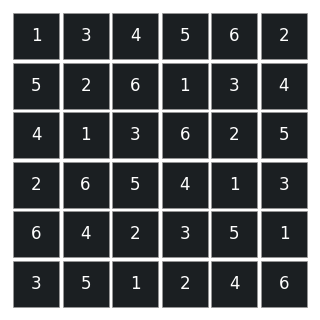

In [40]:
mini_sudoku.solve()
mini_sudoku.show()

Which corresponds exactly to the solution of the game, as expected.

:::{figure} ../assets/2-how-to-solve/4-mini-sudoku/solution.png
:alt: Mini Sudoku solution
:label: mini-sudoku-solution
:align: center
:width: 60%
Mini Sudoku No. 60's Solution _Source: [LinkedIn Mini Sudoku](https://www.linkedin.com/games/mini-sudoku)_
:::

---

# References

- TAKANO, Kevin; DE FREITAS, Rosiane and DE SÁ, Vinícius Gusmão. O jogo de lógica Sudoku: modelagem teórica, NP-Completude e estratégias algorítmicas exatas e heurísticas. In: CONCURSO DE TRABALHOS DE INICIAÇÃO CIENTÍFICA DA SBC (CTIC-SBC), 34., 2015, Recife. Anais […]. Porto Alegre: Sociedade Brasileira de Computação, 2015. p. 71–80.
- Sudoku. [Wikipedia](https://en.wikipedia.org/wiki/Sudoku). May 7{sup}`th`, 2025. Accessed on October 10{sup}`th`, 2025.